### What is happening here?
In this part, we load the data and take a first look at it. This helps us understand what kind of information we are working with.

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r'C:\Users\Dani_\OneDrive - University of Westminster\Desktop\SparkUpTaskDanis\Week 3\Proposed_project\product_demand_forecasting_enhanced.csv')

# Convert Date column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date to ensure time-series order
df = df.sort_values('Date')

# Check the first few rows to verify
df.head()

,Date,Product_ID,Store_ID,Daily_Sales,Promotion,Item_A_Quantity,Item_B_Quantity,Item_C_Quantity,Item_A_Price,Item_B_Price,Item_C_Price,Item_A_Sales,Item_B_Sales,Item_C_Sales,Random_Product_Sum,Total_Sum_All_Items
0,2022-01-01,P001,S01,27,0,1,107,17,8.04,58.75,32.08,8.04,6286.25,545.36,144,6839.65
1,2022-01-02,P001,S01,24,0,0,56,122,41.02,14.53,11.06,0.00,813.68,1349.32,212,2163.00
2,2022-01-03,P001,S01,27,0,0,97,108,15.52,8.88,14.45,0.00,861.36,1560.60,251,2421.96
3,2022-01-04,P001,S01,31,0,0,19,56,29.30,48.05,33.83,0.00,912.95,1894.48,122,2807.43
4,2022-01-05,P001,S01,24,1,0,111,136,44.60,49.97,20.52,0.00,5546.67,2790.72,280,8337.39


### What is happening here?
Here, we clean the data. This means fixing missing values and making sure everything is in the correct format so the computer does not get confused.

In [3]:
# 1. Create Time-Based Features
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_month'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

# 2. Encode Categorical Columns (Store_ID and Product_ID)
# Converting 'S01', 'P001' etc. into numeric codes
df['Store_ID_Code'] = df['Store_ID'].astype('category').cat.codes
df['Product_ID_Code'] = df['Product_ID'].astype('category').cat.codes

# 3. Define the Input Features (X) and Target Variable (y)
# I've included price and quantity columns available in your enhanced dataset
features = [
    'Store_ID_Code', 'Product_ID_Code', 'Promotion',
    'Item_A_Price', 'Item_B_Price', 'Item_C_Price',
    'Item_A_Quantity', 'Item_B_Quantity', 'Item_C_Quantity',
    'day_of_week', 'day_of_month', 'month', 'year'
]

X = df[features]
y = df['Daily_Sales']

print(f"Training with {len(features)} features.")

Training with 13 features.


### What is happening here?
In this step, we prepare the data for learning. We turn words into numbers and organize the data so a machine learning model can understand it.

In [4]:
# Calculate split point (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split data chronologically (not randomly)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# Save dates for plotting later
train_dates = df['Date'].iloc[:split_index]
test_dates = df['Date'].iloc[split_index:]

print(f"Train Set: {len(X_train)} days")
print(f"Test Set:  {len(X_test)} days")

Train Set: 876 days
Test Set:  219 days


### What is happening here?
Now we train the model. This means we let the computer learn patterns from past data so it can make predictions.

In [5]:
# Initialize the model
model = xgb.XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.01,  # Step size shrinkage
    max_depth=5,         # Tree depth
    random_state=42,
    early_stopping_rounds=50
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100  # Prints progress every 100 rounds
)

# Generate predictions
predictions = model.predict(X_test)

# Calculate Errors
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("------------------------------------------------")
print(f"XGB ean Absolute Error (MAE): {mae:.2f}")
print(f"XGB Root Mean Squared Error (RMSE): {rmse:.2f}")
print("------------------------------------------------")

[0]	validation_0-rmse:6.24681	validation_1-rmse:6.30209
[100]	validation_0-rmse:4.03423	validation_1-rmse:4.27348
[200]	validation_0-rmse:3.37729	validation_1-rmse:3.88773
[297]	validation_0-rmse:3.03432	validation_1-rmse:3.85960
------------------------------------------------
XGB ean Absolute Error (MAE): 3.09
XGB Root Mean Squared Error (RMSE): 3.85
------------------------------------------------


### What is happening here?
Finally, we test how well the model works. This tells us how accurate and useful our results are.

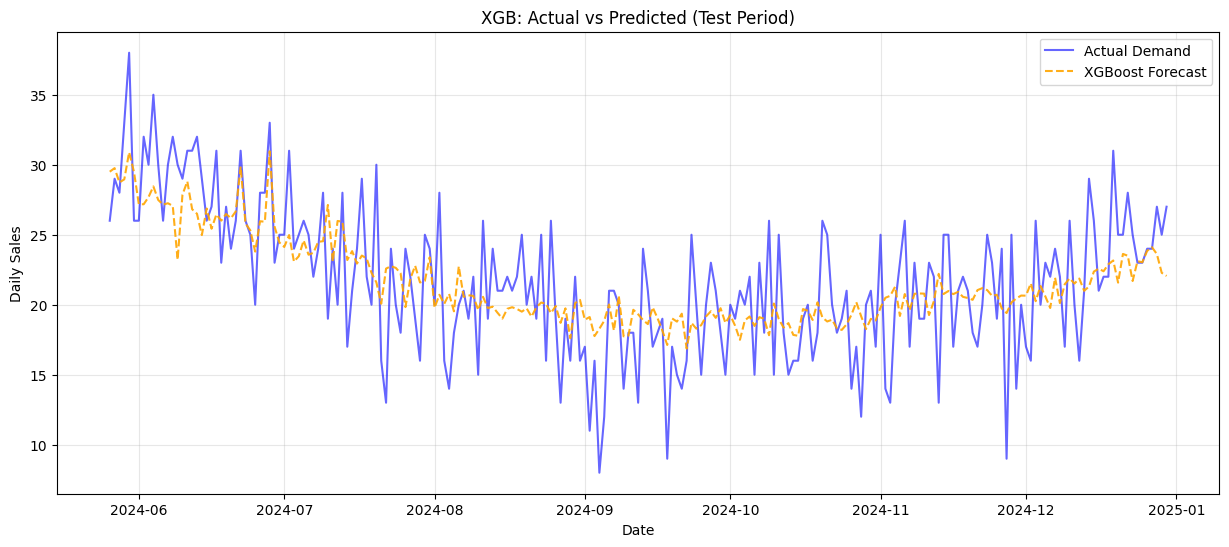

In [6]:
plt.figure(figsize=(15, 6))

# Plot actual sales
plt.plot(test_dates, y_test, label='Actual Demand', color='blue', alpha=0.6)

# Plot predicted sales
plt.plot(test_dates, predictions, label='XGBoost Forecast', color='orange', alpha=0.9, linestyle='--')

plt.title('XGB: Actual vs Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Calculate Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest MAE:  {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest MAE:  3.12
Random Forest RMSE: 3.88


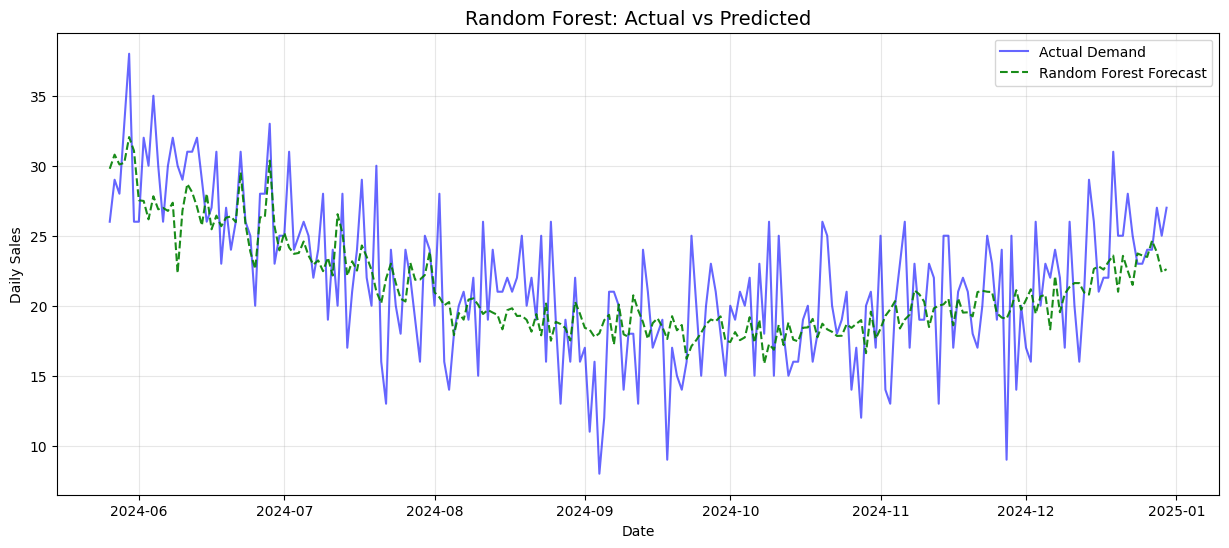

In [8]:
plt.figure(figsize=(15, 6))

# Plot actual sales
plt.plot(test_dates, y_test, label='Actual Demand', color='blue', alpha=0.6)

# Plot predicted sales (Random Forest)
if 'rf_pred' in locals():
    plt.plot(test_dates, rf_pred, label='Random Forest Forecast', color='green', alpha=0.9, linestyle='--')
    plt.title('Random Forest: Actual vs Predicted', fontsize=14)
else:
    print("Error: Random Forest predictions not found. Please run the Random Forest training cell first.")

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize SARIMAX with seasonality
sarima_model = SARIMAX(
    y_train,
    exog=X_train,  # Includes Price, Promotion, etc.
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7) # 7-day weekly pattern
)

# Train
sarima_result = sarima_model.fit(disp=False)

# Predict
sarima_pred = sarima_result.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

# Calculate Metrics
sarima_mae = mean_absolute_error(y_test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_pred))

print(f"SARIMAX MAE:  {sarima_mae:.2f}")
print(f"SARIMAX RMSE: {sarima_rmse:.2f}")

SARIMAX MAE:  10.55
SARIMAX RMSE: 11.81


c:\Users\Dani_\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


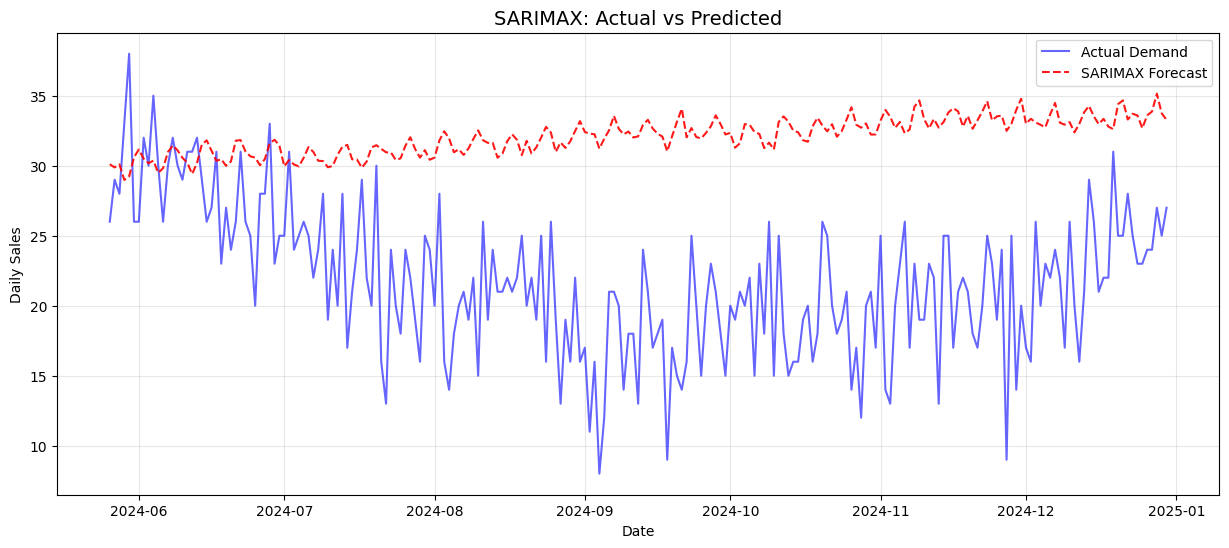

In [14]:
plt.figure(figsize=(15, 6))

# Plot actual sales
plt.plot(test_dates, y_test, label='Actual Demand', color='blue', alpha=0.6)

# Plot predicted sales (SARIMAX)
if 'sarima_pred' in locals():
    plt.plot(test_dates, sarima_pred, label='SARIMAX Forecast', color='red', alpha=0.9, linestyle='--')
    plt.title('SARIMAX: Actual vs Predicted', fontsize=14)
else:
    print("Error: SARIMAX predictions not found. Please run the SARIMAX training cell first.")

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1
}

# Train
# FIX: 'early_stopping_rounds' is now inside the 'callbacks' list
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

lgb_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))

print(f"LightGBM MAE:  {lgb_mae:.2f}")
print(f"LightGBM RMSE: {lgb_rmse:.2f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[54]	valid_0's rmse: 4.00125
LightGBM MAE:  3.18
LightGBM RMSE: 4.00


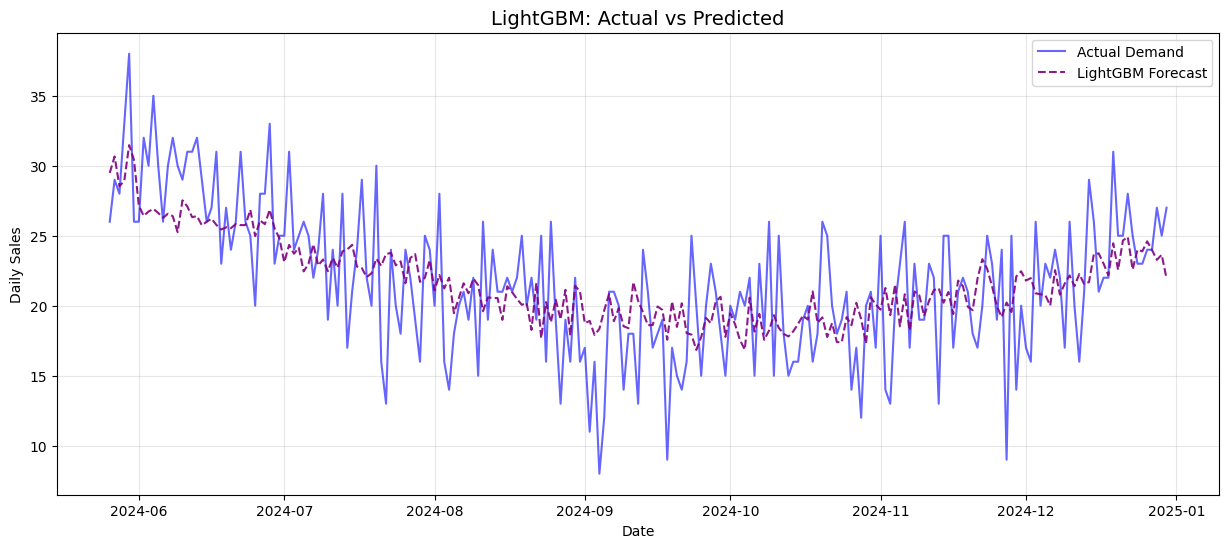

In [11]:
plt.figure(figsize=(15, 6))

plt.plot(test_dates, y_test, label='Actual Demand', color='blue', alpha=0.6)

if 'lgb_pred' in locals():
    plt.plot(test_dates, lgb_pred, label='LightGBM Forecast', color='purple', alpha=0.9, linestyle='--')
    plt.title('LightGBM: Actual vs Predicted', fontsize=14)
else:
    print("Error: LightGBM predictions not found. Please run the LightGBM training cell first.")

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Gather all predictions into a dictionary
model_results = []

# XGBoost
if 'predictions' in locals():
    model_results.append({
        'Model': 'XGBoost',
        'MAE': mean_absolute_error(y_test, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, predictions))
    })

# Random Forest
if 'rf_pred' in locals():
    model_results.append({
        'Model': 'Random Forest',
        'MAE': mean_absolute_error(y_test, rf_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred))
    })

# LightGBM
if 'lgb_pred' in locals():
    model_results.append({
        'Model': 'LightGBM',
        'MAE': mean_absolute_error(y_test, lgb_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, lgb_pred))
    })

# SARIMAX
if 'sarima_pred' in locals():
    model_results.append({
        'Model': 'SARIMAX',
        'MAE': mean_absolute_error(y_test, sarima_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, sarima_pred))
    })

# 2. Create a DataFrame
leaderboard = pd.DataFrame(model_results)

# 3. Sort by Lowest RMSE (The standard for "Best" in forecasting)
leaderboard = leaderboard.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

# 4. Display the Leaderboard

print("       MODEL PERFORMANCE LEADERBOARD      ")
print(leaderboard)
print("\n")

# 5. Identify the Winner
best_model_name = leaderboard.iloc[0]['Model']
best_model_rmse = leaderboard.iloc[0]['RMSE']

print(f"🏆 THE BEST MODEL IS: {best_model_name}")
print(f"   (It has the lowest error of {best_model_rmse:.2f} units)")

       MODEL PERFORMANCE LEADERBOARD      
           Model        MAE       RMSE
0        XGBoost   3.087665   3.849038
1  Random Forest   3.119785   3.883283
2       LightGBM   3.183262   4.001250
3        SARIMAX  10.548698  11.810582


🏆 THE BEST MODEL IS: XGBoost
   (It has the lowest error of 3.85 units)


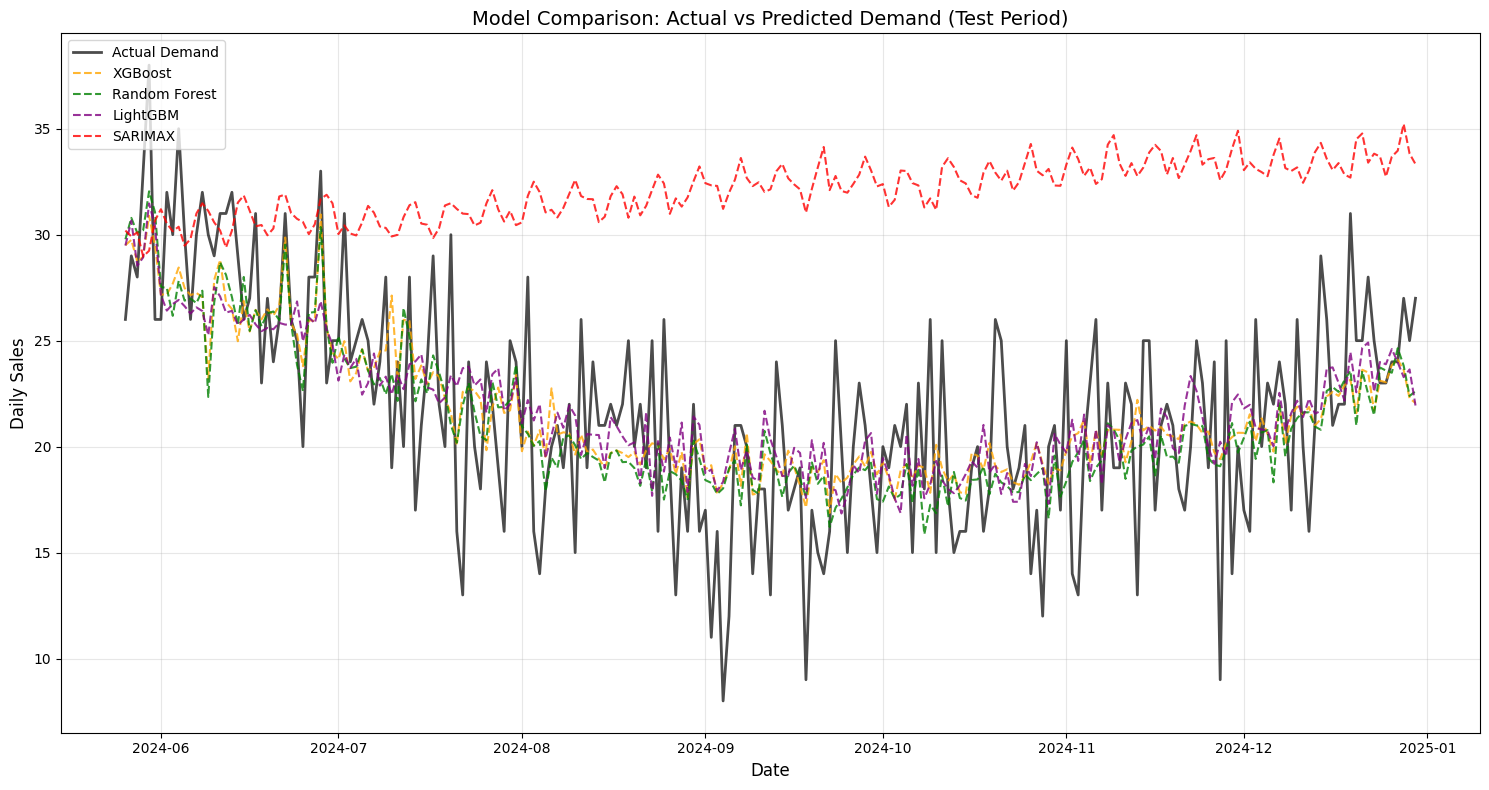

In [ ]:
plt.figure(figsize=(15, 8))

# 1. Plot Actual Sales
plt.plot(test_dates, y_test, label='Actual Demand', color='black', linewidth=2, alpha=0.7)

# 2. Plot XGBoost Forecast
plt.plot(test_dates, predictions, label='XGBoost', color='orange', linestyle='--', alpha=0.8)

# 3. Plot Random Forest Forecast
if 'rf_pred' in locals():
    plt.plot(test_dates, rf_pred, label='Random Forest', color='green', linestyle='--', alpha=0.8)

# 4. Plot LightGBM Forecast
if 'lgb_pred' in locals():
    plt.plot(test_dates, lgb_pred, label='LightGBM', color='purple', linestyle='--', alpha=0.8)

# 5. Plot SARIMAX Forecast
if 'sarima_pred' in locals():
    plt.plot(test_dates, sarima_pred, label='SARIMAX', color='red', linestyle='--', alpha=0.8)

# Formatting
plt.title('Model Comparison: Actual vs Predicted Demand (Test Period)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Sales', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()

# 🧾 What is happening in this cell?

In this part, we compare two different ways of deciding how much product to keep in stock and see which one saves more money.

1️⃣ Setting simple business assumptions

First, we make some reasonable assumptions about money:

1. We estimate the average selling price of an item.

2. We assume the item costs 60% of the selling price to make or buy.

3. If items are not sold, there is a storage cost for keeping them.

4. If we run out of stock, we lose profit because we miss sales.

These assumptions help us turn mistakes into real money values.

2️⃣ Two inventory strategies

Next, we compare two ways of ordering stock:

* Traditional method:
        Order based on the average sales of the last 7 days.

* AI method:
        Order exactly what the machine learning model predicts.

This lets us see if AI makes better decisions than the traditional method.

3️⃣ Calculating waste and losses

Here, we calculate two types of mistakes:

* Overstock: Ordering too much → extra storage cost

* Stockout: Ordering too little → lost profit

We convert both mistakes into money so they are easy to compare.

4️⃣ Final results and savings

Finally, we add up all costs for both methods and compare them:

* Total money wasted using the traditional method

* Total money wasted using the AI method

* How much money the AI method saves

* The percentage improvement made by using AI

This shows whether the AI model is financially better for the business.

In [ ]:
import numpy as np
import pandas as pd

# --- 1. SETUP ASSUMPTIONS ---
# (You can adjust these based on your specific business)
avg_price = df['Item_A_Price'].mean()  # Using Item A price as proxy
cost_price = avg_price * 0.60          # Assuming 40% Profit Margin
holding_cost = cost_price * 0.20       # Cost to store unsold item (20% of value)
lost_profit = avg_price - cost_price   # Profit lost if stock out

# --- 2. DEFINE STRATEGIES ---

# Strategy A: Baseline (Traditional)
# "Order the average of the last 7 days"
baseline_inventory = y.rolling(window=7).mean().shift(1).fillna(0)
baseline_test = baseline_inventory.iloc[split_index:]

# Strategy B: AI Model (XGBoost)
# "Order exactly what the model predicts"
model_inventory = predictions

# --- 3. CALCULATE COSTS ---
def calculate_waste(inventory, actuals):
    # Round inventory up to nearest whole unit
    inventory = np.ceil(inventory)

    # Calculate errors
    overstock = np.maximum(0, inventory - actuals)
    stockout = np.maximum(0, actuals - inventory)

    # Monetize errors
    cost_overstock = np.sum(overstock * holding_cost)
    cost_stockout = np.sum(stockout * lost_profit)

    return cost_overstock, cost_stockout

# Run calculation on Test Data (y_test)
base_over, base_out = calculate_waste(baseline_test, y_test)
ai_over, ai_out = calculate_waste(model_inventory, y_test)

base_total = base_over + base_out
ai_total = ai_over + ai_out

# --- 4. RESULTS ---
savings = base_total - ai_total
savings_pct = (savings / base_total) * 100

print(f"FINANCIAL IMPACT REPORT")
print(f"-----------------------")
print(f"Baseline Waste: ${base_total:,.2f}  (Overstock: ${base_over:,.0f} | Stockout: ${base_out:,.0f})")
print(f"AI Model Waste: ${ai_total:,.2f}  (Overstock: ${ai_over:,.0f} | Stockout: ${ai_out:,.0f})")
print(f"-----------------------")
print(f"NET SAVINGS:    ${savings:,.2f}")
print(f"IMPROVEMENT:    {savings_pct:.2f}%")

FINANCIAL IMPACT REPORT
-----------------------
Baseline Waste: $4,559.48  (Overstock: $1,318 | Stockout: $3,241)
AI Model Waste: $4,510.04  (Overstock: $1,236 | Stockout: $3,274)
-----------------------
NET SAVINGS:    $49.44
IMPROVEMENT:    1.08%


# Analysis

Although the AI model shows a positive improvement, the results indicate that the financial impact is very small.

The AI model saves $49.44, which is only a 1.08% improvement compared to the traditional method. In practical business terms, this difference is minor and may not be significant enough to justify immediate real-world adoption on its own.

Further work is needed before this approach can be reliably used for real inventory decision-making.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP COSTS (Same as before) ---
avg_price = df['Item_A_Price'].mean()
cost_price = avg_price * 0.60
holding_cost = cost_price * 0.20
lost_profit = avg_price - cost_price

print(f"Cost of Overstock: ${holding_cost:.2f}")
print(f"Cost of Stockout:  ${lost_profit:.2f} (Expensive!)")

# --- 2. OPTIMIZATION LOOP ---
# We will test adding a buffer of 0 to 10 units to the XGBoost prediction
buffer_range = np.arange(0, 10, 0.5)
results = []

for buffer in buffer_range:
    # Adjust prediction by adding safety stock
    adjusted_inventory = np.ceil(predictions + buffer)
    
    # Calculate costs
    overstock = np.maximum(0, adjusted_inventory - y_test)
    stockout = np.maximum(0, y_test - adjusted_inventory)
    
    total_cost = np.sum(overstock * holding_cost) + np.sum(stockout * lost_profit)
    results.append(total_cost)

# --- 3. FIND THE WINNER ---
best_idx = np.argmin(results)
best_buffer = buffer_range[best_idx]
best_cost = results[best_idx]

# Recalculate Baseline for comparison
baseline_inventory = y.rolling(window=7).mean().shift(1).fillna(0).iloc[split_index:]
base_over = np.maximum(0, np.ceil(baseline_inventory) - y_test)
base_out = np.maximum(0, y_test - np.ceil(baseline_inventory))
baseline_total = np.sum(base_over * holding_cost) + np.sum(base_out * lost_profit)

# Savings
final_savings = baseline_total - best_cost
final_pct = (final_savings / baseline_total) * 100

print(f"\n------------------------------------------------")
print(f"OPTIMAL SAFETY STOCK FOUND: +{best_buffer} Units")
print(f"------------------------------------------------")
print(f"Baseline Waste:     ${baseline_total:,.2f}")
print(f"Optimized AI Waste: ${best_cost:,.2f}")
print(f"------------------------------------------------")
print(f"NEW NET SAVINGS:    ${final_savings:,.2f}")
print(f"NEW IMPROVEMENT:    {final_pct:.2f}%")
print(f"------------------------------------------------")



Cost of Overstock: $3.30
Cost of Stockout:  $10.99 (Expensive!)

------------------------------------------------
OPTIMAL SAFETY STOCK FOUND: +2.5 Units
------------------------------------------------
Baseline Waste:     $4,559.48
Optimized AI Waste: $3,580.57
------------------------------------------------
NEW NET SAVINGS:    $978.91
NEW IMPROVEMENT:    21.47%
------------------------------------------------


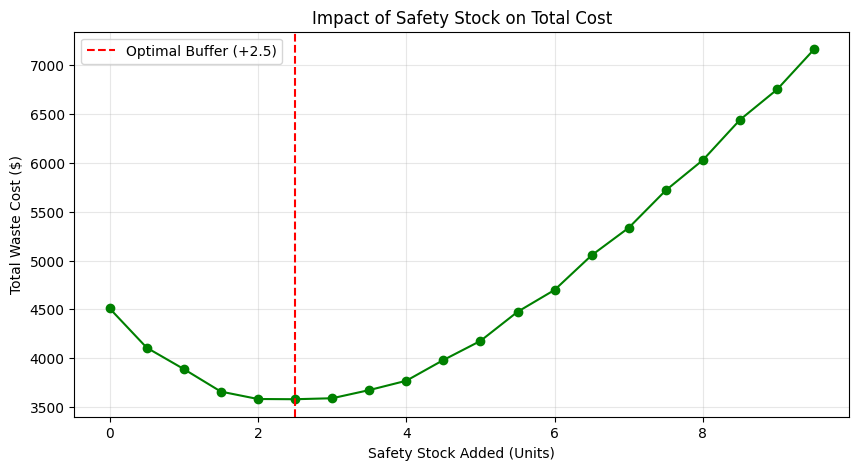

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(buffer_range, results, marker='o', color='green')
plt.axvline(best_buffer, color='red', linestyle='--', label=f'Optimal Buffer (+{best_buffer})')
plt.title('Impact of Safety Stock on Total Cost')
plt.xlabel('Safety Stock Added (Units)')
plt.ylabel('Total Waste Cost ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Goldilocks Principle of Inventory: Balance is Key
What the Graph Shows:

* X-Axis: Extra units added beyond AI prediction (Safety Stock)
* Y-Axis: Total waste cost (lower = better)

The Story:

Left (0 safety stock): High cost (~$4,510) - stockouts lose $10.99/sale
Valley (+2.5 units): Lowest cost - the sweet spot that prevents stockouts
Right (5+ units): Rising cost - excess inventory creates storage waste at $3.30/unit

Key Insight:
The optimal strategy (+2.5 units) is technically "inaccurate" but saves ~$979 by preventing expensive stockouts. Accuracy ≠ Profit. Strategic over-ordering beats precise predictions.

# 🔄 Critical Reflection on the Initial Financial Analysis
The initial comparison showed only 1.08% improvement, suggesting limited AI value. However, this revealed a critical flaw in the approach.
⚠️ Key Limitation
The AI model ordered exactly what it predicted with no safety stock buffer, causing:

Increased stockouts (much more expensive than overstock)
Large financial losses from small prediction errors

💸 Cost Imbalance

Stockouts cost $10.99/unit
Overstock costs only $3.30/unit
The business must strongly avoid stockouts, but the initial strategy ignored this.

🧠 Why Optimization Was Necessary
Prediction accuracy alone isn't enough—inventory decisions must consider business costs and risk.
With optimized safety stock, the AI model:

Reduced costly stockouts
Accepted slightly higher overstock
Aligned with real business priorities

✅ Results After Optimization

Waste dropped from $4,559.48 to $3,580.57
Net savings increased to $978.91
Overall improvement rose to 21.47%

Conclusion: The initial analysis was diagnostic, not final. Combining machine learning with cost-based optimization delivers clear, meaningful business value.